# MODELLO FEED-FORWARD DENSE

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D, Dropout, Input
import tensorflow_datasets as tfds


In [2]:
(train_images,train_labels),(test_images,test_labels) = cifar10.load_data()#scarico il datset cifar 10 che contiene di 10 categorie di immagini

#assegno i nomi alle 10 classi
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 36s 0us/step


In [ ]:
print(f"Train set: {train_images.shape}, Test set: {test_images.shape}") # il dataset contiene in tot 60000 immagini di cui 50k per il train e 10k per il test

print(train_labels.shape) #vediamo la struttura delle etichette
#print(train_labels)

#vediamo la struttura delle immagini
#print(train_images)
print(train_images.shape)

Train set: (50000, 32, 32, 3), Test set: (10000, 32, 32, 3)
(50000, 1)
(50000, 32, 32, 3)


Cifar-10 contiene 60k immagini divise in 10 categorie:
*   il train-set contiene 50k immagini
*   il test-set contiene 10k immagini

le immagini sono 32x32x3 dove 32 indica il nr di pixel in altezza e largezza e 3 indica i colori (rgb)

Le etichette come possiamo vedere sono un array in cui è indicato il valore della classe (non ordinabile) --> 1-10

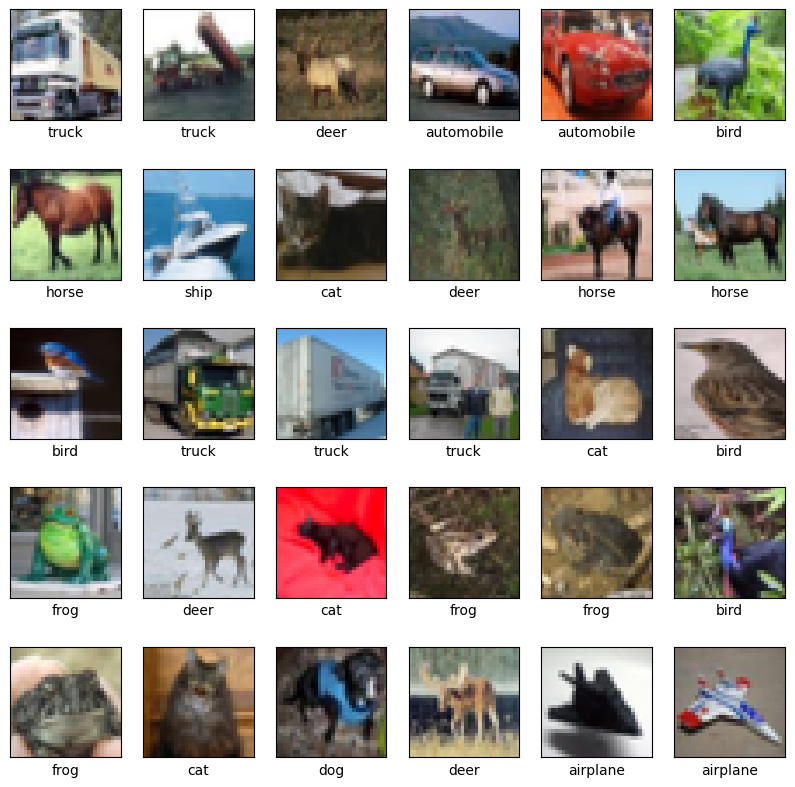

In [ ]:
#mostro le prima 30 immagini con le rispettive etichette
plt.figure(figsize=(10,10))
for i in range(1,31):
  plt.subplot(5,6,i)
  plt.imshow(train_images[i])
  plt.xlabel(class_names[train_labels[i][0]])
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)

In [3]:
#normalizzo le immagini
train_images = train_images.astype("float32") / 255
test_images = test_images.astype("float32") / 255

#trasformo nel formato one-hot le labels
train_labels = to_categorical(train_labels,10)
test_labels = to_categorical(test_labels,10)

In [ ]:
#creo il modello feed-forward Dense
input_layer = Input(shape=(32,32,3))
#dato che le immagini sono tridimensionali faccio il flattening
x = Flatten()(input_layer)

#inserisco gli strati dense
x = Dense(512, activation='relu')(x)
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
output_layer = Dense(10, activation='softmax')(x) #qui il nr di neuroni = 10 è obbligato e anche la softmax pk ho 10 classi

#creo il modello
model_ffd = models.Model(inputs=input_layer, outputs=output_layer)#gli passo input e output

#lo compilo
model_ffd.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

#lo alleno inserendo usando earlystop per evitare under e overfitting (mi fermo quando la val_accuracy aumenta per 5 epoche consecutive)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_ffd = model_ffd.fit(train_images, train_labels,epochs=60, batch_size=128,validation_split=0.2,callbacks=[early_stopping])



Epoch 1/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.2484 - loss: 2.0712 - val_accuracy: 0.3658 - val_loss: 1.7971
Epoch 2/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3848 - loss: 1.7190 - val_accuracy: 0.3568 - val_loss: 1.8023
Epoch 3/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4114 - loss: 1.6499 - val_accuracy: 0.4191 - val_loss: 1.6382
Epoch 4/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4395 - loss: 1.5662 - val_accuracy: 0.4302 - val_loss: 1.5982
Epoch 5/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4537 - loss: 1.5163 - val_accuracy: 0.4364 - val_loss: 1.5925
Epoch 6/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4700 - loss: 1.4846 - val_accuracy: 0.4400 - val_loss: 1.5694
Epoch 7/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4834 - loss: 1.4484 - val_accuracy: 0.4646 - val_loss: 1.4980
Epoch 8/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4978 - loss: 1.4152 - val_accuracy: 0

In [ ]:
print(model_ffd.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3072)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       1,573,376 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,216,672 (19.90 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,477,782 (13.27 MB)

None


possiamo vedere che il nostro modello ha oltre 5 milioni di parametri con solo 3 strati fortemente connessi

In [ ]:
#funzioni per fare grafici di loss e accuracy
def grafico_loss(history):
  import matplotlib.pyplot as plt
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.title('Training vs Validation Loss')
  plt.legend()
  plt.show()

def grafico_accuracy(history):
  import matplotlib.pyplot as plt
  plt.plot(history.history['accuracy'], label='Training Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.title('Training vs Validation Accuracy')
  plt.legend()
  plt.show()

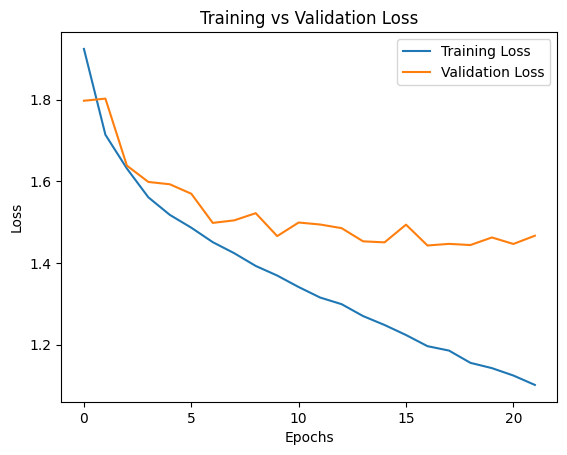

In [ ]:
#rappresentazione grafica della loss e della validation loss della rete ffd

#grafico loss
grafico_loss(history_ffd)


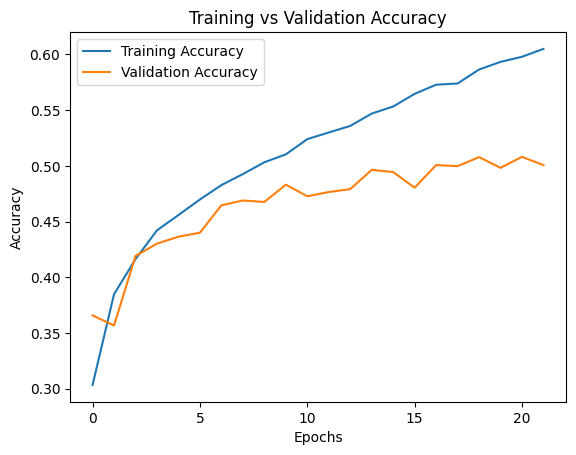

In [ ]:
#grafico accuracy
grafico_accuracy(history_ffd)


In [ ]:
print(model_ffd.evaluate(test_images,test_labels))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5130 - loss: 1.4104
[1.4184454679489136, 0.5081999897956848]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step


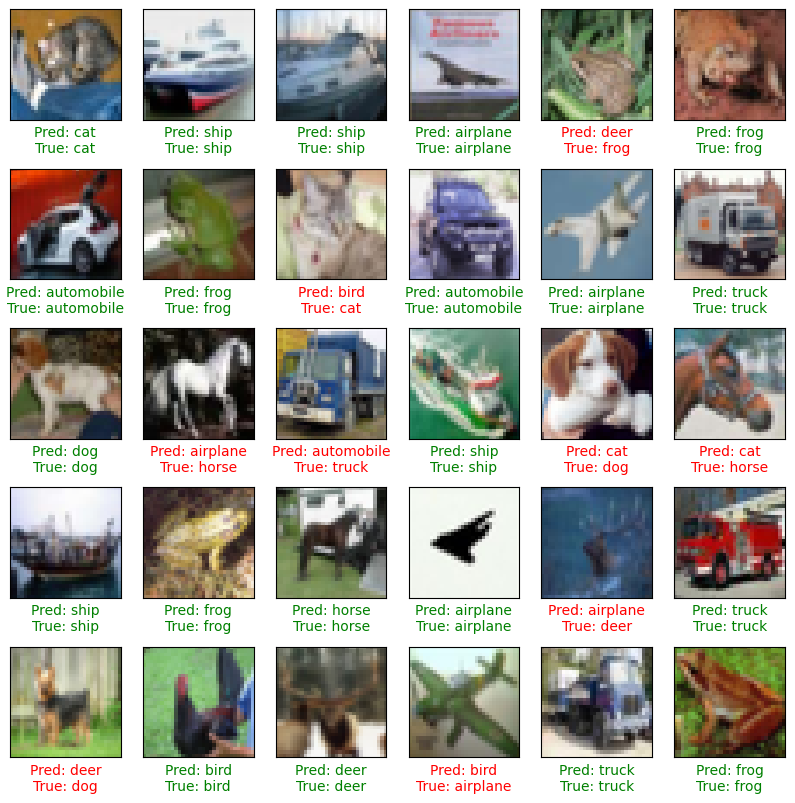

In [ ]:
#seleziono le prime 30 immagini del test set
num_images = 30
test_images_plot = test_images[:num_images]
#converto da formato one-hot a indice
test_labels_plot = np.argmax(test_labels[:num_images], axis=1)

#previsioni sulle img
predictions = model_ffd.predict(test_images_plot)
#prendo la classe con prob maggiore
predicted_labels = np.argmax(predictions, axis=1)  # Classe con probabilità più alta

#faccio il grafico
plt.figure(figsize=(10, 10))

for i in range(num_images):
    plt.subplot(5, 6, i + 1)
    plt.imshow(test_images_plot[i])

    #etichette reali e predette
    true_label = class_names[test_labels_plot[i]]
    predicted_label = class_names[predicted_labels[i]]

    #imposto la scritta verde se la previsione è corretta e rossa se è sbagliata
    color = "green" if predicted_label == true_label else "red"
    plt.xlabel(f"Pred: {predicted_label}\nTrue: {true_label}", color=color)

    plt.xticks([])
    plt.yticks([])
    plt.grid(False)


# VALUTAZIONE DEL MODELLO FEED-FORWARD DENSE
Il modello ffd come possiamo vedere ha un accuracy del 50% e la loss di 1.4.
Questo non è un risultato ottimale ma posssiamo dire che il modello ha cmq imparato qualcosa dato che la probabilità iniziale dividendo casualmente le immagini sarebbe stata del 10%

SPIEGAZIONE DEL RISULTATO OTTENUTO:
il risultato ottenuto è dato dal fatto che siamo costretti ad appiattire le immagini utilizzando flatten, diconseguenza trasformiamo immagini di 3 dimensioni in un vettore di 3072 valori non riuscendo quindi a catturare informazioni spaziali e pattern specifici.

Sicuramente con un modello convoluzionale potremmo ottenere una precisione maggiore.

# RETE CONVOLUZIONALE

In [4]:
inputs = Input(shape=(32,32,3))

#primo strato convoluzionale con 64 filtri
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu", padding="same")(inputs)
x = layers.MaxPooling2D(pool_size=2)(x)

#secondo strato convoluzionale con 128 filtri
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu", padding="same")(x) #ho deciso di applicare il pendig per far si che le feature maps siano della stessa grandezza dell'input
x = layers.MaxPooling2D(pool_size=2)(x)

#terzo strato convoluzionale con 256 filtri
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu", padding="same")(x)

#quarto strato convoluzionale con 512 filtri
x = layers.Conv2D(filters=512, kernel_size=3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

#flattening
x = layers.Flatten()(x)

#primo strato dense
x = layers.Dense(256, activation="relu")(x)

#drop out --> ad ogni epoca disattivo il 60% dei neuroni
x = Dropout(0.6)(x)

#secondo strato Dense con 128 neuroni
x = layers.Dense(128, activation="relu")(x)

#ultimo strato dense con softmax per classificare le 10 classi
outputs = layers.Dense(10, activation="softmax")(x)

#creazione del modello
model = models.Model(inputs=inputs, outputs=outputs)

#compilo il modello
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#addestro il modello
history_conv = model.fit(train_images, train_labels,epochs=60, batch_size=128,validation_split=0.2,callbacks=[early_stopping])

Epoch 1/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.2363 - loss: 1.9988 - val_accuracy: 0.4975 - val_loss: 1.3809
Epoch 2/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.4888 - loss: 1.3995 - val_accuracy: 0.5691 - val_loss: 1.1821
Epoch 3/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.5889 - loss: 1.1533 - val_accuracy: 0.6543 - val_loss: 0.9600
Epoch 4/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6494 - loss: 0.9909 - val_accuracy: 0.6949 - val_loss: 0.8643
Epoch 5/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.6964 - loss: 0.8625 - val_accuracy: 0.7194 - val_loss: 0.8045
Epoch 6/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7383 - loss: 0.7529 - val_accuracy: 0.7292 - val_loss: 0.7929
Epoch 7/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.7704 - loss: 0.6543 - val_accuracy: 0.7369 - val_loss: 0.7633
Epoch 8/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8008 - loss: 0.5736 - val

In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       2,097,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,047,712 (42.14 MB)

 Trainable params: 3,682,570 (14.05 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,365,142 (28.10 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Test feature maps (10000, 32, 32, 64)
Image feature maps (32, 32, 64)


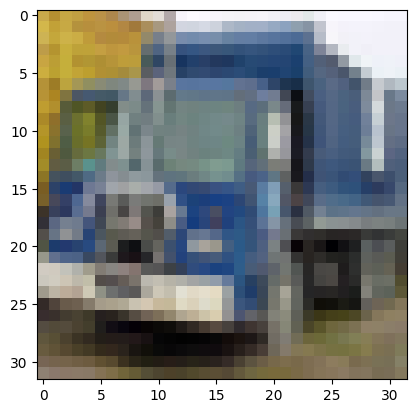

In [5]:
layer_nr = 1

feature_map = model.layers[layer_nr].output
feature_maps_model = Model(inputs=model.input, outputs=feature_map)
test_feature_maps = feature_maps_model.predict(test_images)

image_nr = 14
print("Test feature maps",  test_feature_maps.shape)
print("Image feature maps", test_feature_maps[image_nr].shape)
plt.imshow(test_images[image_nr])






In [6]:
from tensorflow.image import resize

layer_nr = 2  # Assicurati che sia un indice di un layer convoluzionale
test_images_resized = resize(test_images, [32, 32])

feature_map = model.layers[layer_nr].output
feature_maps_model = Model(inputs=model.input, outputs=feature_map)



test_feature_maps = feature_maps_model.predict(test_images_resized)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


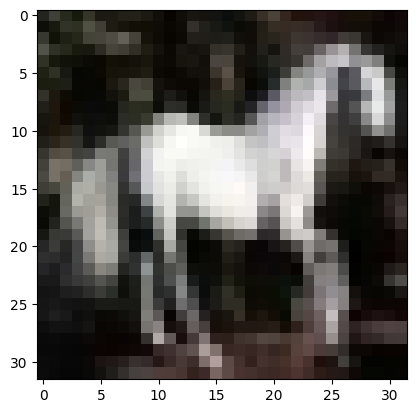

In [7]:
image_nr = 13
img = test_images[image_nr]


plt.imshow(img)
plt.show()

Test feature maps (10000, 16, 16, 64)
Image feature maps (16, 16, 64)


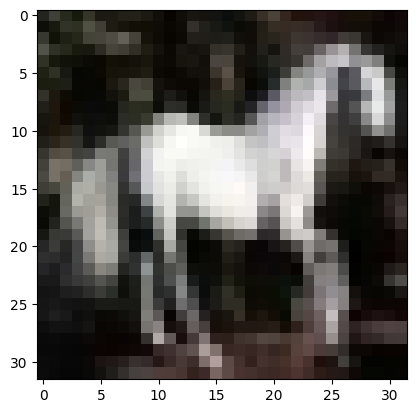

In [8]:
image_nr = 13
print("Test feature maps",  test_feature_maps.shape)
print("Image feature maps", test_feature_maps[image_nr].shape)
plt.imshow(test_images[image_nr])
#plt.xlabel(class_names[test_labels[image_nr][0]])

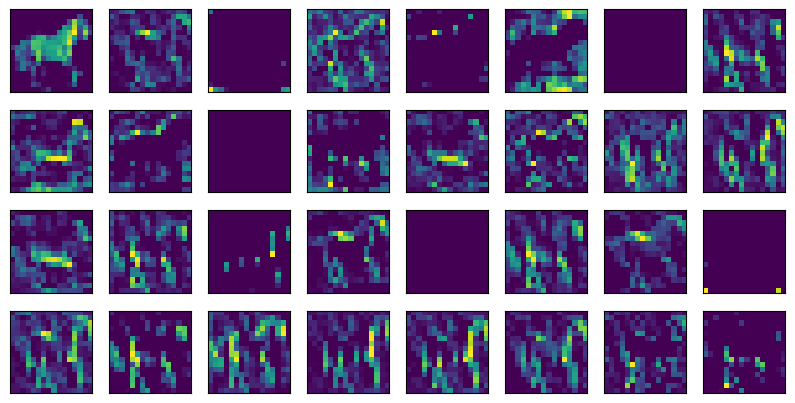

In [9]:
plt.figure(figsize=(10,5))
for i in range(32):              # visualizziamo le feature maps
  plt.subplot(4,8,i+1)
  plt.imshow(test_feature_maps[image_nr,:,:,i])
  plt.xticks([])
  plt.yticks([])

In [10]:
#grafico loss
grafico_loss(history_conv)

NameError: name 'grafico_loss' is not defined

nelle prime epoche sia la loss che la validation loss calano rapidamente indicando che il modello sta imparando;
dalla settima epoca iniziano i primi segnali di overfitting dato che le due curve iniziano a divergere.

In [ ]:
#grafico accuracy
grafico_accuracy(history_conv)

dopo circa 7 8 epoche il modello inizia a sovradattarsi ai dati ma raggiungiamo cmq un accuracy significativa

In [ ]:
print(model.evaluate(test_images,test_labels))

In [ ]:
#seleziono le prime 30 immagini del test set
num_images = 30
test_images_plot = test_images[:num_images]
#converto da formato one-hot a indice
test_labels_plot = np.argmax(test_labels[:num_images], axis=1)

#previsioni sulle img
predictions = model.predict(test_images_plot)
#prendo la classe con prob maggiore
predicted_labels = np.argmax(predictions, axis=1)  # Classe con probabilità più alta

#faccio il grafico
plt.figure(figsize=(10, 10))

for i in range(num_images):
    plt.subplot(5, 6, i + 1)
    plt.imshow(test_images_plot[i])

    #etichette reali e predette
    true_label = class_names[test_labels_plot[i]]
    predicted_label = class_names[predicted_labels[i]]

    #imposto la scritta verde se la previsione è corretta e rossa se è sbagliata
    color = "green" if predicted_label == true_label else "red"
    plt.xlabel(f"Pred: {predicted_label}\nTrue: {true_label}", color=color)

    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

# CONSIDERAZIONI SUL MODELLO CONVOLUZIONALE
il modello convoluzionale, come era prevedibile ha raggiunto un'accuratezza del 76% e una loss pari allo 0.7 in quanto grazie alle convoluzioni riusciamo a catturare pattern molto piu significativi rispetto a una semplice rete connessa (forward-dense) e soprattutto non essendo costretti a fare il flattening fin dal primo layer riusciamo a catturare anche l'aspetto spaziale delle immagini (relazioni tra pixel vicini) che con il primo modello non riusciamo a fare.

In generale possiamo dire che questo modello riesce a classificare le 10 categorie di immagini di cifar-10 in modo abbastanza preciso.

Sicuramente con un modello preaddestrato utilizzando la tecnica del trasfer-learning potremmo raggiungere livelli di accuratezza migliori, soprattutto usando un modello allenato su molte piu immagini.

# MODELLO PREADDESTRATO CON TRASFER-LEARNING

In [ ]:
#prendo il modello EfficientNetB0 escludendo gli ultimi layers di classificazione con i pesi allenati su imagenet
conv_base = keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3) #sarebbe ideale (224x224x3) e fare il resize ma crusha colab
)
conv_base.trainable = False  #congelo i pesi preaddestrati

#creo i layers finali per adattarli al mio caso
inputs = keras.Input(shape=(32, 32, 3))
x = conv_base(inputs)
x = layers.GlobalAveragePooling2D()(x) #lo uso al posto del flattening per evitare overfitting --> se per es ho una feature map 7x7x1280 diventa un vettore di 1280 dove ogni valore rappresenta la media di un solo layer 7x7
x = layers.BatchNormalization()(x) #normalizza i batch per ogni input e aggiunge due pesi per ogni canale della feature map
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation="softmax")(x)

model_transfer = keras.Model(inputs, outputs)

#compilo il modello
model_transfer.compile(loss="categorical_crossentropy",
              optimizer=keras.optimizers.Adam(learning_rate=0.001),
              metrics=["accuracy"])

#metto 2 condizioni di callback
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6) #dimezza il LR se il modello non migliora

#alleno il modello
history_transfer = model_transfer.fit(
    train_images, train_labels,
    validation_split=0.2,
    epochs=20,
    batch_size=32, #normalemnete avrei messo un batch piu alto ma se faccio altrimenti colab crusha
    callbacks=[early_stopping, lr_scheduler]
)



16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.1107 - loss: 2.4598 - val_accuracy: 0.1277 - val_loss: 2.2945 - learning_rate: 0.0010
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.1193 - loss: 2.2922 - val_accuracy: 0.1377 - val_loss: 2.2842 - learning_rate: 0.0010
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.1169 - loss: 2.2856 - val_accuracy: 0.1054 - val_loss: 2.2830 - learning_rate: 0.0010
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.1255 - loss: 2.2788 - val_accuracy: 0.1386 - val_loss: 2.2729 - learning_rate: 0.0010
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.1279 - loss: 2.2745 - val_accuracy: 0.1143 - val_loss: 2.2731 - learning_rate: 0.0010
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.1338 - loss: 2.2689 - val_accuracy: 0.1703 - val_loss: 2.2472 - learning_rate: 0.0010
Epoch 7/20
1250/1

In [ ]:
conv_base.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 32, 32, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 32, 32, 3)      │              0 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 32, 32, 3)      │              7 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 32, 32, 3)      │              0 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 33, 33, 3)      │              0 │ rescaling_1[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 16, 16, 32)     │            864 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 16, 16, 32)     │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 16, 16, 32)     │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 16, 16, 32)     │            288 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 16, 16, 32)     │            128 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 16, 16, 32)     │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 32)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 32)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 8)        │            264 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model_transfer.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 1, 1, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,555,587 (17.38 MB)

 Trainable params: 167,818 (655.54 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

 Optimizer params: 335,638 (1.28 MB)

possiamo vedere come avendo bloccato i pesi del modelloEfficientNetB0 gran parte dei parametri sono non-trainable, mentre sono modificabili solo i pesi degli ultimi layers

In [ ]:
#valutazione del modello
test_loss, test_acc = model_transfer.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1521 - loss: 2.2451
Test accuracy: 0.154


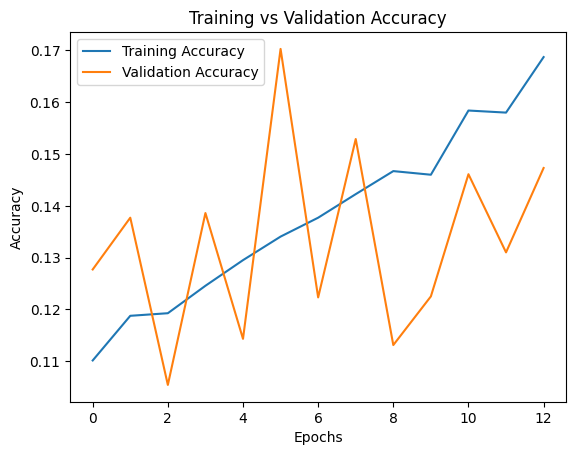

In [ ]:
grafico_accuracy(history_transfer)

in generale l'accuracy del modello è molto bassa, durante il training riesce lentamente a imparare le featurs delle immagini ma non riesce a generalizzare in quanto la validation_accuracy è molto bassa e oscilla troppo.

Possiamo dire che questo modello non è adatto a questo dataset principalmente a causa della scarsa risoluzione delle immagini di cifar10

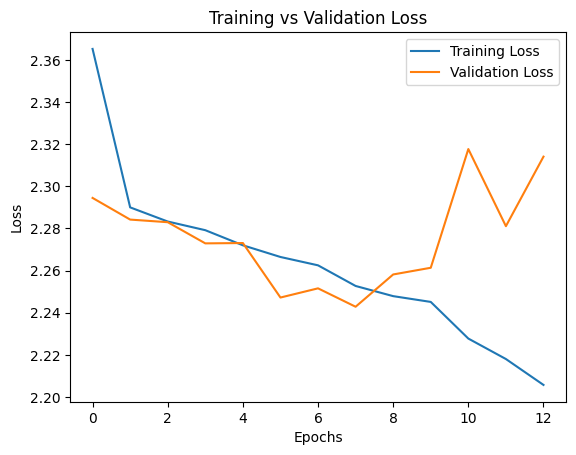

In [ ]:
grafico_loss(history_transfer)

nelle prime epoche, la validation loss segue un trend simile alla training loss.
dopo la metà dell'addestramento, la validation loss inizia ad aumentare mentre la training loss continua a diminuire.
Questo è un chiaro segnale di overfitting, il modello sta memorizzando troppo i dati di training e perde la capacità di generalizzare su dati nuovi.
La training loss rimane cmq altissima pari a circa 2,2 indicando che il modello riesce a fare poco meglio del caso (il caso in questo caso è  -ln(0,1) = 2,3 )

In [ ]:
print(model_transfer.evaluate(test_images,test_labels))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1521 - loss: 2.2451
[2.243978977203369, 0.15449999272823334]


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


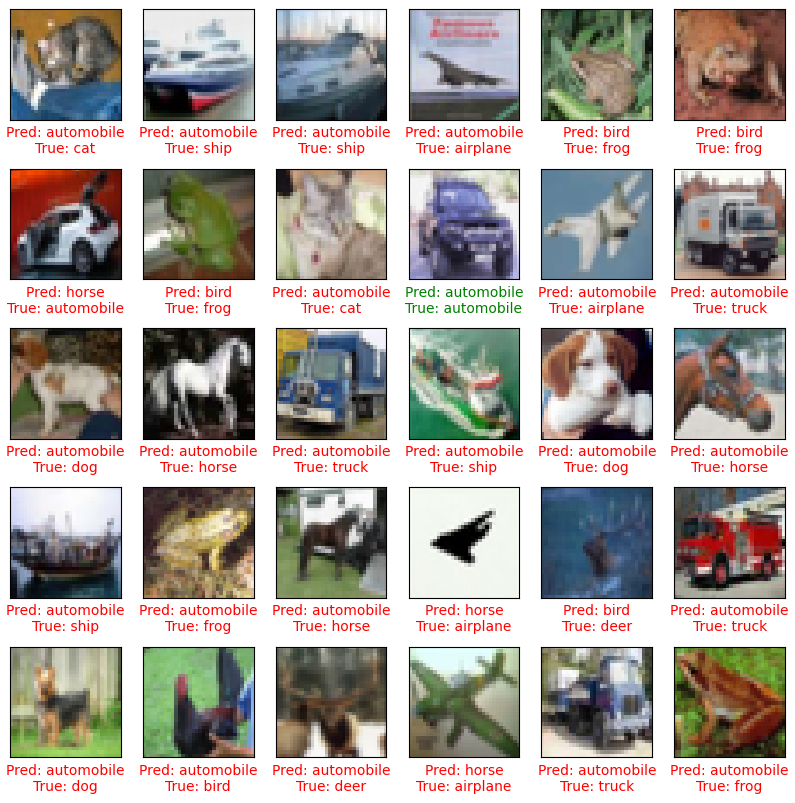

In [ ]:
#seleziono le prime 30 immagini del test set
num_images = 30
test_images_plot = test_images[:num_images]
#converto da formato one-hot a indice
test_labels_plot = np.argmax(test_labels[:num_images], axis=1)

#previsioni sulle img
predictions = model_transfer.predict(test_images_plot)
#prendo la classe con prob maggiore
predicted_labels = np.argmax(predictions, axis=1)  # Classe con probabilità più alta

#faccio il grafico
plt.figure(figsize=(10, 10))

for i in range(num_images):
    plt.subplot(5, 6, i + 1)
    plt.imshow(test_images_plot[i])

    #etichette reali e predette
    true_label = class_names[test_labels_plot[i]]
    predicted_label = class_names[predicted_labels[i]]

    #imposto la scritta verde se la previsione è corretta e rossa se è sbagliata
    color = "green" if predicted_label == true_label else "red"
    plt.xlabel(f"Pred: {predicted_label}\nTrue: {true_label}", color=color)

    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

# CONCLUSIONI SU TRANSFER-LEARNING CON EfficientNetB0 SU CIFAR10
utilizzando questo modello allenato su imagenet (dataset ad alta risoluzione) su cifar-10 non riusciamo a cogliere le feature delle immagini e quindi a classificarle, infatti abbiamo una loss molto alta (2,2) e un'accuracy di 0,12 (guadagna solo 2 pt percentuale rispetto alla classificazione a caso)


# PROVO IL MODELLO CON TRASFER LEARNING SU UN DATASET AD ALTA RISOLUZIONE

In [ ]:
#carico cat vs dog
splits = ['train[:70%]', 'train[70%:85%]', 'train[85%:]'] #faaccio le suddivisioni train, valid_trai  e test
(dataset_train, dataset_val, dataset_test), info = tfds.load('cats_vs_dogs', split=splits, with_info=True, as_supervised=True)

class_names = ['cat', 'dog']

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.55XHS2_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [ ]:
#vedo la grandezza delle prime 5 img
for image, label in dataset_train.take(5):
    print(image.shape)

print("Numero totale di immagini:", info.splits["train"].num_examples)


(262, 350, 3)
(409, 336, 3)
(493, 500, 3)
(375, 500, 3)
(240, 320, 3)
Numero totale di immagini: 23262


possiamo vedere che ogni immagine ha una dimensione differente di conseguenza è necessario fare un resizing per renderle tutte uguale

In [ ]:
#funzione per il preproccessing
def preprocess_data(image, label):
    image = tf.image.resize(image, (256, 256)) #faccio il resizing
    return image, label

#lo applico su tutto il dataset
dataset_train = dataset_train.map(preprocess_data).shuffle(1000).batch(64).prefetch(tf.data.AUTOTUNE)
dataset_val = dataset_val.map(preprocess_data).batch(64).prefetch(tf.data.AUTOTUNE)
dataset_test = dataset_test.map(preprocess_data).batch(64).prefetch(tf.data.AUTOTUNE)


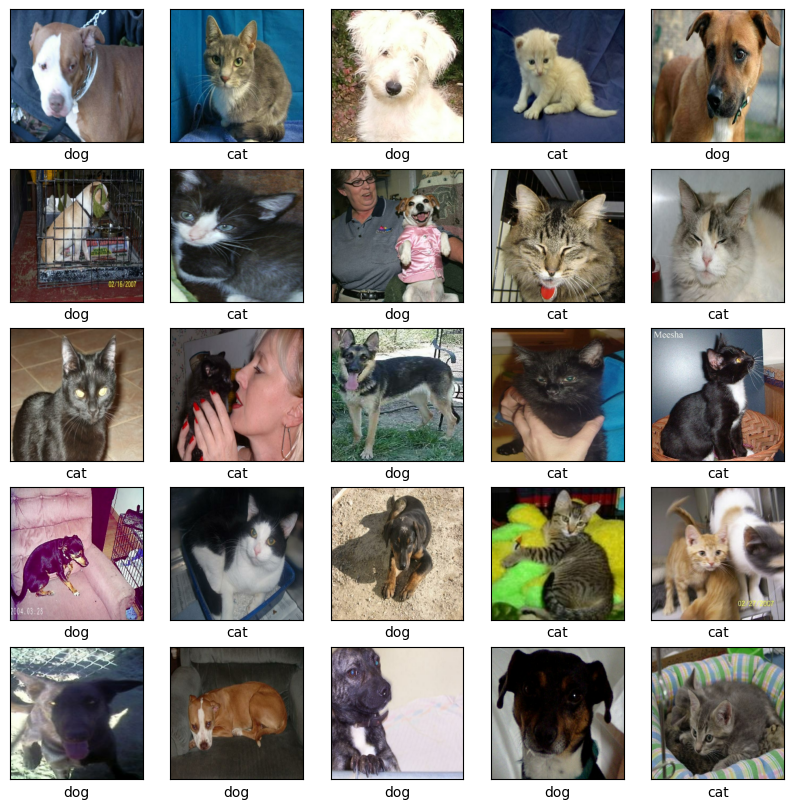

In [ ]:
#visualizzo 25 immagini del dataset
plt.figure(figsize=(10,10))
for i, (image, label) in enumerate(dataset_train.unbatch().take(25)):
    plt.subplot(5,5,i+1)
    plt.imshow(image.numpy().astype("uint8"))
    plt.xticks([])
    plt.yticks([])
    plt.xlabel(class_names[label.numpy()])

In [ ]:
#uso il modello base con i pesi congelati
conv_base = keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(256, 256, 3)
)
conv_base.trainable = False

inputs = keras.Input(shape=(256, 256, 3))
x = keras.applications.efficientnet.preprocess_input(inputs)  #preprocessa l'input
x = conv_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(2, activation="softmax")(x)  #2 classi

model_efficient_net = keras.Model(inputs, outputs)

#compilo il modello
model_efficient_net.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              metrics=["accuracy"])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
conv_base.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_2 (Rescaling)   │ (None, 256, 256, 3)    │              0 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization_1           │ (None, 256, 256, 3)    │              7 │ rescaling_2[0][0]      │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_3 (Rescaling)   │ (None, 256, 256, 3)    │              0 │ normalization_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 257, 257, 3)    │              0 │ rescaling_3[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 128, 128, 32)   │            864 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 128, 128, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 128, 128, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 128, 128, 32)   │            288 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 128, 128, 32)   │            128 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 128, 128, 32)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 32)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 32)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 8)        │            264 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model_efficient_net.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 8, 8, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,221,925 (16.11 MB)

 Trainable params: 172,354 (673.26 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
#early Stopping
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

#training del modello
history_efficiente_net = model_efficient_net.fit(
    dataset_train,
    validation_data=dataset_val,
    epochs=15,
    callbacks=[early_stopping]
)



Epoch 1/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 95s 254ms/step - accuracy: 0.8315 - loss: 0.3628 - val_accuracy: 0.9937 - val_loss: 0.0280
Epoch 2/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 40s 150ms/step - accuracy: 0.9856 - loss: 0.0507 - val_accuracy: 0.9934 - val_loss: 0.0212
Epoch 3/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 47s 175ms/step - accuracy: 0.9904 - loss: 0.0354 - val_accuracy: 0.9937 - val_loss: 0.0198
Epoch 4/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 48s 182ms/step - accuracy: 0.9922 - loss: 0.0262 - val_accuracy: 0.9934 - val_loss: 0.0193
Epoch 5/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 39s 143ms/step - accuracy: 0.9915 - loss: 0.0263 - val_accuracy: 0.9940 - val_loss: 0.0190
Epoch 6/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 40s 149ms/step - accuracy: 0.9931 - loss: 0.0215 - val_accuracy: 0.9943 - val_loss: 0.0187
Epoch 7/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 36s 133ms/step - accuracy: 0.9936 - loss: 0.0219 - val_accuracy: 0.9943 - val_loss: 0.0182
Epoch 8/15
255/255 ━━━━━━━━━━━━━━━━━━━━ 47s 178ms/step - accuracy: 0.9951 - loss: 0

In [ ]:
#valuto il modello sul test
test_loss, test_acc = model_efficient_net.evaluate(dataset_test)

55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 223ms/step - accuracy: 0.9901 - loss: 0.0274


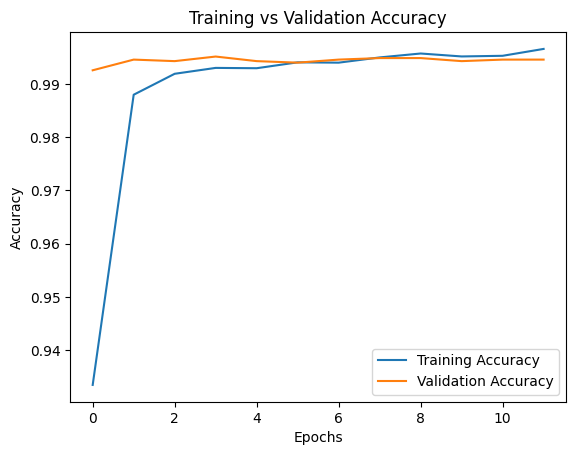

In [ ]:
grafico_accuracy(history_efficiente_net)

L'accuracy in training parte da circa 0.94 e sale quasi immediatamente sopra 0,98 fino a raggiungere 0,99.
Le curve di training e validazione sono molto vicine, indicando che il modello generalizza molto bene.

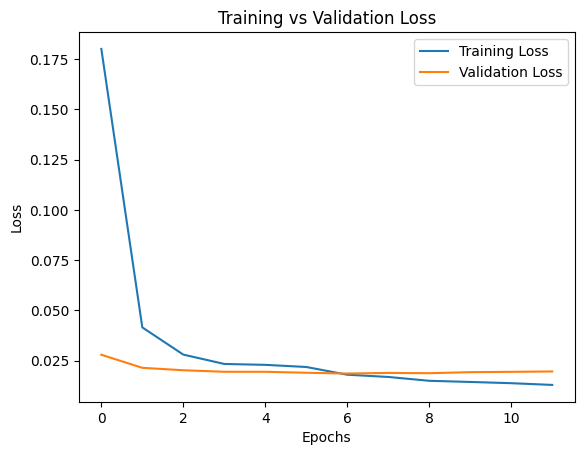

In [ ]:
grafico_loss(history_efficiente_net)

le curve di training e validazione rimangono vicine, il che indica che il modello generalizza bene e non c'è presenza di overfitting (se non in minima parte dalla sesta epoca in poi).


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


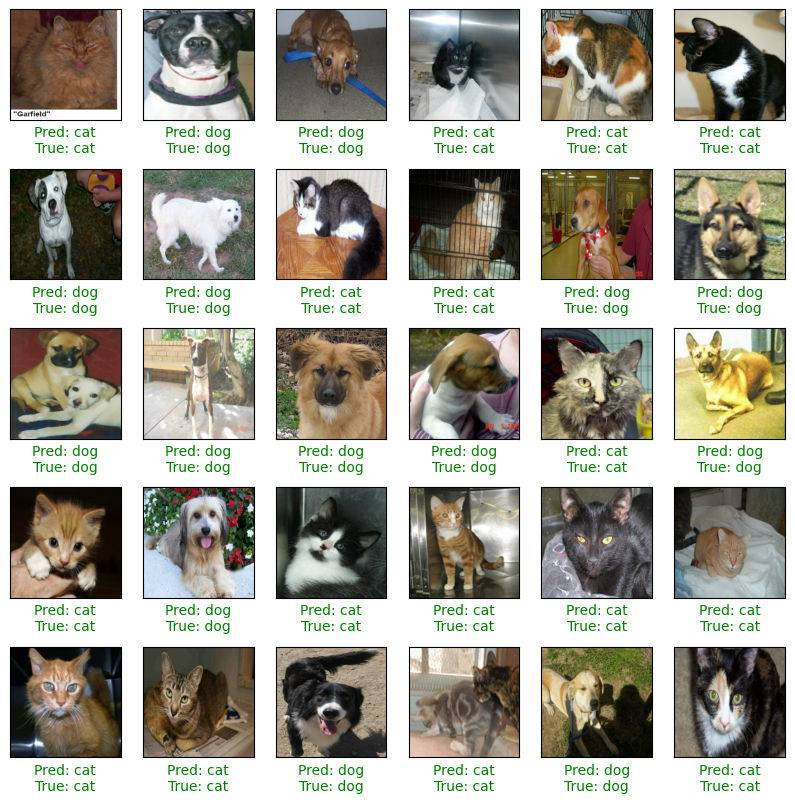

In [ ]:
#visualizzo le previsioni che fa il modello sulle immagini
num_images = 30

test_images = []
test_labels = []
for image, label in dataset_test.unbatch().take(num_images):
    test_images.append(image.numpy())
    test_labels.append(label.numpy())

test_images = np.array(test_images)
test_labels = np.array(test_labels)

#faccio i predict
predictions = model_efficient_net.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

#faccio il plot
plt.figure(figsize=(10, 10))
for i in range(num_images):
    plt.subplot(5, 6, i + 1)
    plt.imshow(test_images[i].astype("uint8"))
    true_label = class_names[test_labels[i]]
    predicted_label = class_names[predicted_labels[i]]
    color = "green" if predicted_label == true_label else "red"
    plt.xlabel(f"Pred: {predicted_label}\nTrue: {true_label}", color=color)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

#CONCLUSIONI SU MODELLO DI TRANSFER LEARNING SU CAT VS DOG
come potevamo aspettarci il modello che utilizza i pesi di EfficientNetB0 con transfer learning risulta essere ottimale dato che è stato allenato su imagenet che contiene diverse categorie di cani e gatti.